In [72]:
%%bash
conda activate open2c-env
conda info --env


CommandNotFoundError: Your shell has not been properly configured to use 'conda activate'.
To initialize your shell, run

    $ conda init <SHELL_NAME>

Currently supported shells are:
  - bash
  - fish
  - tcsh
  - xonsh
  - zsh
  - powershell

See 'conda init --help' for more information and options.

IMPORTANT: You may need to close and restart your shell after running 'conda init'.




# conda environments:
#
base                     /sharehome/gibcus/miniconda3
HiNT-env                 /sharehome/gibcus/miniconda3/envs/HiNT-env
biopython-env            /sharehome/gibcus/miniconda3/envs/biopython-env
eaglec-env               /sharehome/gibcus/miniconda3/envs/eaglec-env
open2c-env            *  /sharehome/gibcus/miniconda3/envs/open2c-env



# Compartmentalization via eigendecomposition

In [73]:
# os.environ["HDF5_USE_FILE_LOCKING"]="FALSE"

In [2]:
# import standard python libraries
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.max_open_warning'] = 0

import os, subprocess
import pandas as pd

# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting
import pyBigWig

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

In [45]:
dataDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers/'
outDataDir = f'/abyss/gibcus/data/UM1/compartments'
genomeDir = f'/abyss/gibcus/data/UM1/genome'
figureDir = f'/sharehome/xiangruhuo/4DN_scripts/plot'


conditions = [
#     'DE_R1','DE_R2',
     'H1_DE','H1_DEp1','H1_DEp2','H1_DEp3','H1_DEp4','H1_DEp5','H1_DEp6','H1_DEp7','H1_HB',
#    'H9_Nup_DE','H9_Nup_DEp1','H9_Nup_DEp2','H9_Nup_DEp3','H9_Nup_DEp4','H9_Nup_DEp5','H9_Nup_DEp6','H9_Nup_DEp7','H9_Nup_HB',
#     'HB_R1','HB_R2'
]

example = conditions[0]

# note that there is 1 lane of R1 and R2 libraries to reduce size

long_names = {
    'DE_R1': 'DE-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'DE_R2': 'DE-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
    'H1_DE': 'DE_HiC3_20240517',
    'H1_DEp1': 'DEp1_HiC3_20240517',
    'H1_DEp2': 'DEp2_HiC3_20240517',
    'H1_DEp3': 'DEp3_HiC3_20240517',
    'H1_DEp4': 'DEp4_HiC3_20240517',
    'H1_DEp5': 'DEp5_HiC3_20240517',
    'H1_DEp6': 'DEp6_HiC3_20240517',
    'H1_DEp7': 'DEp7_HiC3_20240517',
    'H1_HB': 'HB_HiC3_20240517',
    'H9_Nup_DE': 'H9ESCNup155_DE_20241021',
    'H9_Nup_DEp1': 'H9ESCNup155_DEp1_20241021',
    'H9_Nup_DEp2': 'H9ESCNup155_DEp2_20241021',
    'H9_Nup_DEp3': 'H9ESCNup155_DEp3_20241021',
    'H9_Nup_DEp4': 'H9ESCNup155_DEp4_20241021',
    'H9_Nup_DEp5': 'H9ESCNup155_DEp5_20241021',
    'H9_Nup_DEp6': 'H9ESCNup155_DEp6_20241021',
    'H9_Nup_DEp7': 'H9ESCNup155_DEp7_20241021',
    'H9_Nup_HB': 'H9ESCNup155_HB_20241021',
    'HB_R1': 'HB-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'HB_R2': 'HB-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
}
    
colors = {
    'DE_R1': '#999999',
    'DE_R2': '#cccccc',
    'H1_DE': '#ffffcc',
    'H1_DEp1': '#ffeda0',
    'H1_DEp2': '#fed976',
    'H1_DEp3': '#feb24c',
    'H1_DEp4': '#fd8d3c',
    'H1_DEp5': '#fc4e2a',
    'H1_DEp6': '#e31a1c',
    'H1_DEp7': '#bd0026',
    'H1_HB': '#800026',
    'H9_Nup_DE': '#ffffcc',
    'H9_Nup_DEp1': '#ffeda0',
    'H9_Nup_DEp2': '#fed976',
    'H9_Nup_DEp3': '#feb24c',
    'H9_Nup_DEp4': '#fd8d3c',
    'H9_Nup_DEp5': '#fc4e2a',
    'H9_Nup_DEp6': '#e31a1c',
    'H9_Nup_DEp7': '#bd0026',
    'H9_Nup_HB': '#800026',
    'HB_R1': '#000000',
    'HB_R2': '#333333',
}

binsize = 100_000

cooler_path = {}
for cond in conditions:
            cooler_path[cond] = f'{dataDir}/{long_names[cond]}.hg38.mapq_30.1000.mcool::/resolutions/{binsize}'


clrs = {
    cond: cooler.Cooler(cooler_path[cond]) for cond in conditions
}

# Get binned GC-content (proxy for the "A" phase)

In [46]:
## fasta sequence is required for calculating binned profile of GC conent
os.chdir(f'{genomeDir}')
os.getcwd()
if not os.path.isfile('hg38.fa'):
    ## note downloading a ~1Gb file can take a minute
    subprocess.call('wget https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa', shell=True)

In [47]:
import bioframe
bins = {}
gc_cov = {}

for cond in conditions:
    print("calculating... " +cond)

    os.chdir(f'{genomeDir}')
    bins[cond] = clrs[cond].bins()[:]
    hg38_genome = bioframe.load_fasta('hg38.fa');

    ## note the next command may require installing pysam
    os.chdir(f'{outDataDir}')
    if not os.path.isfile(f'{long_names[cond]}_hg38_gc_cov_{binsize//1000}kb.tsv'):
        gc_cov[cond] = bioframe.frac_gc(bins[cond][['chrom', 'start', 'end']], hg38_genome)
        gc_cov[cond].to_csv(f'{outDataDir}/{long_names[cond]}_hg38_gc_cov_{binsize//1000}kb.tsv',index=False,sep='\t')
    gc_cov[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}_hg38_gc_cov_{binsize//1000}kb.tsv',sep='\t')

# display(gc_cov[example][0:5])

calculating... H1_DE
calculating... H1_DEp1
calculating... H1_DEp2
calculating... H1_DEp3
calculating... H1_DEp4
calculating... H1_DEp5
calculating... H1_DEp6
calculating... H1_DEp7
calculating... H1_HB


In [48]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
view_df = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

## Select only chromosomes that are present in the cooler.
# hg38_arms = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

# Compute eigenvectors

In [57]:
# obtain first 3 eigenvectors cis
cis_eigs = {}
cis_eigenvector_track_E1 = {}
cis_eigenvector_track_E2 = {}
cis_eigenvector_track_E3 = {}


hg38_chromsizes = bioframe.fetch_chromsizes('hg38')

for cond in conditions:
    os.chdir(f'{outDataDir}')
    print("calculating... " +cond)
    if not os.path.isfile(f'{long_names[cond]}.comp.{binsize//1000}kb.cis.E1.tsv'):
        cis_eigs[cond] = cooltools.eigs_cis(
                            clrs[cond],
                            gc_cov[cond],
                            view_df=view_df,
                            n_eigs=3,
                            )
        # cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
        cis_eigenvector_track_E1[cond] = cis_eigs[cond][1][['chrom','start','end','E1']]
        cis_eigenvector_track_E2[cond] = cis_eigs[cond][1][['chrom','start','end','E2']]
        cis_eigenvector_track_E3[cond] = cis_eigs[cond][1][['chrom','start','end','E3']]

        cis_eigenvector_track_E1[cond].to_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E1.tsv',index=False,sep='\t')
        cis_eigenvector_track_E2[cond].to_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E2.tsv',index=False,sep='\t')
        cis_eigenvector_track_E3[cond].to_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E3.tsv',index=False,sep='\t')

        bioframe.to_bigwig(cis_eigenvector_track_E1[cond], hg38_chromsizes, f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E1.bw')
        bioframe.to_bigwig(cis_eigenvector_track_E2[cond], hg38_chromsizes, f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E2.bw')
        bioframe.to_bigwig(cis_eigenvector_track_E3[cond], hg38_chromsizes, f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E3.bw')

    cis_eigenvector_track_E1[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E1.tsv',sep='\t')
    cis_eigenvector_track_E2[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E2.tsv',sep='\t')
    cis_eigenvector_track_E3[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}.comp.{binsize//1000}kb.cis.E3.tsv',sep='\t')

calculating... H1_DE
calculating... H1_DEp1
calculating... H1_DEp2
calculating... H1_DEp3
calculating... H1_DEp4
calculating... H1_DEp5
calculating... H1_DEp6
calculating... H1_DEp7
calculating... H1_HB


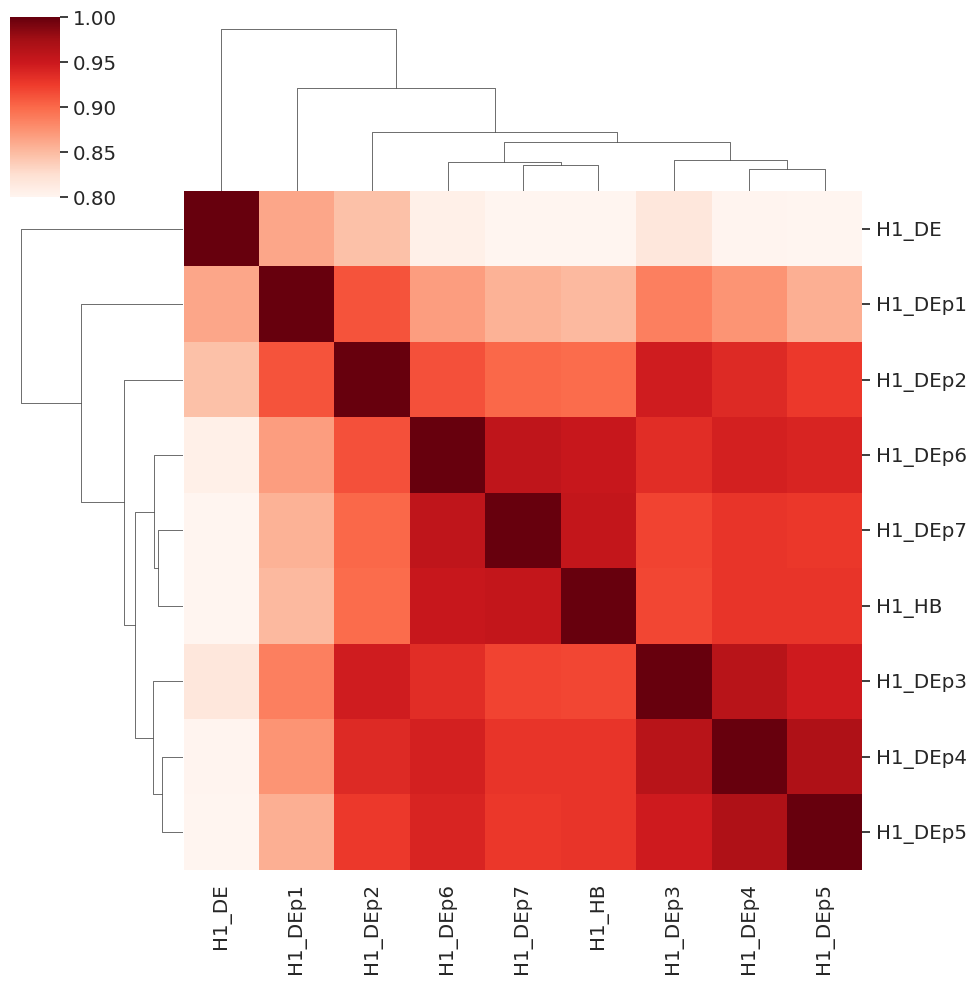

In [50]:
import seaborn as sns

df = pd.DataFrame({cond: cis_eigenvector_track_E1[cond]['E1'] for cond in conditions})
# df = df.dropna()
mat = np.corrcoef(df.dropna(), rowvar=False)
# mat = np.corrcoef(df.apply(lambda x : x.rank()), rowvar=False)
df_corr = pd.DataFrame(mat, columns=df.columns, index=df.columns)
sns.set(font_scale=1.3)
sns.clustermap(df_corr, cmap='Reds',vmin = 0.8)

In [51]:
sns.set(font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False})

# The "saddle" plot

In [52]:
cvd_cis={}

for cond in conditions:
    print("calculating... " +cond)
    os.chdir(f'{outDataDir}')
    if not os.path.isfile(f'{long_names[cond]}_hg38.cvd.{binsize//1000}kb.cis.tsv'):
        cvd_cis[cond] = cooltools.expected_cis(
                clr=clrs[cond],
                view_df=view_df,
        )
        cvd_cis[cond].to_csv(f'{outDataDir}/{long_names[cond]}_hg38.cvd.{binsize//1000}kb.cis.tsv',index=False,sep='\t')
    cvd_cis[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}_hg38.cvd.{binsize//1000}kb.cis.tsv',sep='\t')

calculating... H1_DE
calculating... H1_DEp1
calculating... H1_DEp2
calculating... H1_DEp3
calculating... H1_DEp4
calculating... H1_DEp5
calculating... H1_DEp6
calculating... H1_DEp7
calculating... H1_HB


In [53]:
Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 38 # divide remaining 95% of the genome into 38 equisized groups, 2.5% each

In [54]:
interaction_sum = {}
interaction_count = {}
cvd_cis_fixed = {}

for cond in conditions:
    print("calculating...", cond)

    clr = clrs[cond]

    # Make sure eigenvector track has only required columns
    eigenvector_track = cis_eigenvector_track_E1[cond][
        ["chrom", "start", "end", "E1"]
    ].copy()

    # Recompute expected using the SAME cooler and SAME view_df
    expected = cooltools.expected_cis(
        clr,
        view_df=view_df,
        clr_weight_name="weight",
        nproc=1
    )

    cvd_cis_fixed[cond] = expected

    interaction_sum[cond], interaction_count[cond] = cooltools.saddle(
        clr,
        expected,
        eigenvector_track,
        "cis",
        n_bins=N_GROUPS,
        qrange=(Q_LO, Q_HI),
        view_df=view_df,
        clr_weight_name="weight"
    )

INFO:root:fallback to serial implementation.


calculating... H1_DE


INFO:root:fallback to serial implementation.


calculating... H1_DEp1


INFO:root:fallback to serial implementation.


...

calculating... H1_DEp6


INFO:root:fallback to serial implementation.


calculating... H1_DEp7


INFO:root:fallback to serial implementation.


calculating... H1_HB


In [55]:
import warnings
from cytoolz import merge
def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color="gray",
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot with a square heatmap.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    from functools import partial

    def merge(default, user):
        out = default.copy()
        if user is not None:
            out.update(user)
        return out

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return f"{x:g}"

    # -------------------------
    # Digitize track
    # -------------------------
    track_value_col = track.columns[3]

    digitized_track, _ = cooltools.digitize(
        track,
        n_bins,
        vrange=vrange,
        qrange=qrange
    )

    digitized_col = digitized_track.columns[3]

    # -------------------------
    # Use quantile coordinates
    # -------------------------
    if qrange is None:
        lo, hi = 0.0, 1.0
    else:
        lo, hi = qrange

    binedges = np.linspace(lo, hi, n_bins + 1)

    # -------------------------
    # Remove flanking outlier bins from saddle matrix
    # -------------------------
    C = np.asarray(saddledata).copy()

    if C.shape[0] == n_bins + 2 and C.shape[1] == n_bins + 2:
        C = C[1:-1, 1:-1]

    if C.shape != (n_bins, n_bins):
        raise ValueError(
            f"After trimming, saddledata shape is {C.shape}, "
            f"but expected ({n_bins}, {n_bins})."
        )

    X, Y = np.meshgrid(binedges, binedges)

    # -------------------------
    # Calculate margin values
    # Only use valid bins 1 to n_bins
    # -------------------------
    groupmean = (
        track[track_value_col]
        .groupby(digitized_track[digitized_col])
        .mean()
        .reindex(range(1, n_bins + 1))
        .values
    )

    # -------------------------
    # Figure layout
    # -------------------------
    if subplot_spec is not None:
        GridSpecLocal = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    else:
        GridSpecLocal = GridSpec

    if fig is None:
        fig_kws_default = dict(figsize=(6, 6))
        fig_kws = merge(fig_kws_default, fig_kws)
        fig = plt.figure(**fig_kws)

    gs = GridSpecLocal(
        nrows=3,
        ncols=3,
        width_ratios=[0.22, 1, 0.10],
        height_ratios=[0.22, 1, 0.10],
        wspace=0.05,
        hspace=0.05,
    )

    grid = {}

    # -------------------------
    # Color normalization
    # -------------------------
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only 'linear' and 'log' color scaling are supported.")

    # -------------------------
    # Heatmap
    # -------------------------
    grid["ax_heatmap"] = ax = fig.add_subplot(gs[4])

    heatmap_kws_default = dict(
        cmap=cmap,
        rasterized=True,
        shading="auto"
    )
    heatmap_kws = merge(heatmap_kws_default, heatmap_kws)

    img = ax.pcolormesh(
        X,
        Y,
        C,
        norm=norm,
        **heatmap_kws
    )

    ax.set_xlim(lo, hi)
    ax.set_ylim(hi, lo)

    # Important: force square heatmap
    ax.set_aspect("equal", adjustable="box")

    ax.grid(False)

    # Hide y-axis if you want clean saddle style
    ax.yaxis.set_visible(False)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    # -------------------------
    # Margin bar settings
    # -------------------------
    margin_kws_default = dict(
        edgecolor="k",
        facecolor=color,
        linewidth=1
    )
    margin_kws = merge(margin_kws_default, margin_kws)

    # -------------------------
    # Left margin
    # -------------------------
    grid["ax_margin_y"] = ax_y = fig.add_subplot(gs[3], sharey=grid["ax_heatmap"])

    ax_y.barh(
        binedges[:-1],
        width=groupmean,
        height=np.diff(binedges),
        align="edge",
        **margin_kws
    )

    ax_y.set_ylim(hi, lo)
    ax_y.set_xlim(ax_y.get_xlim()[1], ax_y.get_xlim()[0])

    ax_y.spines["top"].set_visible(False)
    ax_y.spines["bottom"].set_visible(False)
    ax_y.spines["left"].set_visible(False)
    ax_y.xaxis.set_visible(False)

    if ylabel is not None:
        ax_y.set_ylabel(ylabel)

    # -------------------------
    # Top margin
    # -------------------------
    grid["ax_margin_x"] = ax_x = fig.add_subplot(gs[1], sharex=grid["ax_heatmap"])

    ax_x.bar(
        binedges[:-1],
        height=groupmean,
        width=np.diff(binedges),
        align="edge",
        **margin_kws
    )

    ax_x.set_xlim(lo, hi)

    ax_x.spines["top"].set_visible(False)
    ax_x.spines["right"].set_visible(False)
    ax_x.spines["left"].set_visible(False)
    ax_x.xaxis.set_visible(False)
    ax_x.yaxis.set_visible(False)

    if title is not None:
        ax_x.set_title(title)

    # -------------------------
    # Colorbar
    # -------------------------
    grid["ax_cbar"] = ax_cbar = fig.add_subplot(gs[5])

    cbar_kws_default = dict(
        fraction=0.8,
        label=clabel or ""
    )
    cbar_kws = merge(cbar_kws_default, cbar_kws)

    if scale == "linear" and vmin is not None and vmax is not None:
        grid["cbar"] = cb = fig.colorbar(img, cax=ax_cbar, **cbar_kws)

        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)

    else:
        grid["cbar"] = cb = fig.colorbar(
            img,
            cax=ax_cbar,
            format=MinOneMaxFormatter(),
            **cbar_kws
        )
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # -------------------------
    # Final cleanup
    # -------------------------
    grid["fig"] = fig
    grid["img"] = img

    return grid

calculating... H1_DE
calculating... H1_DEp1
calculating... H1_DEp2
calculating... H1_DEp3
calculating... H1_DEp4
calculating... H1_DEp5
calculating... H1_DEp6
calculating... H1_DEp7
calculating... H1_HB


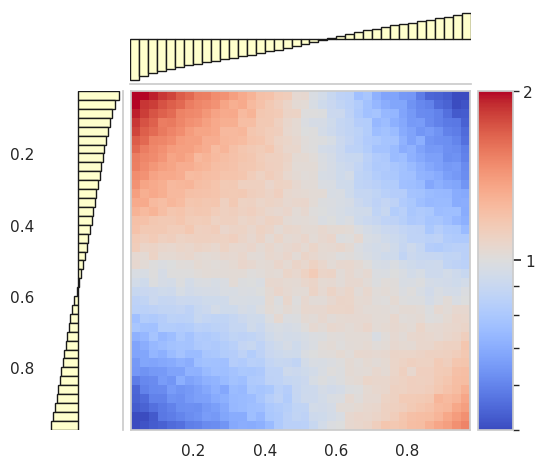

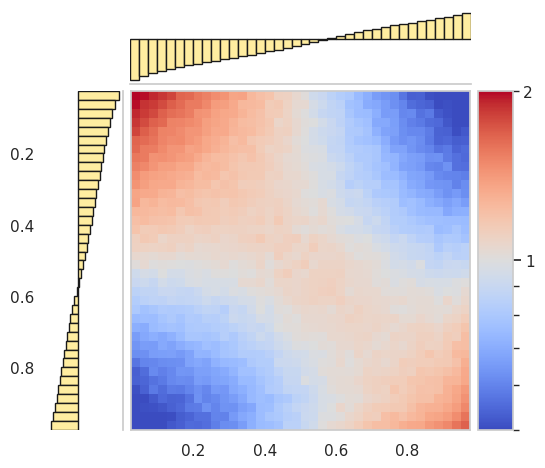

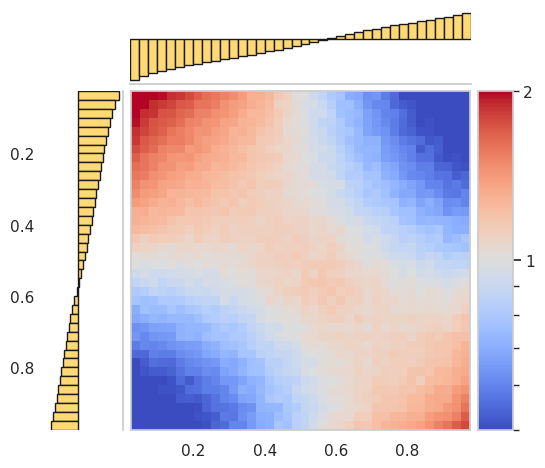

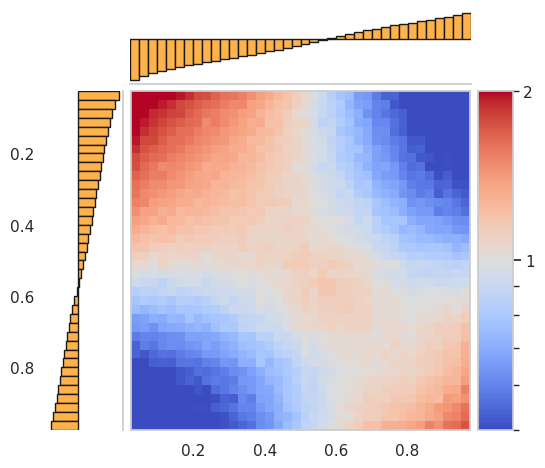

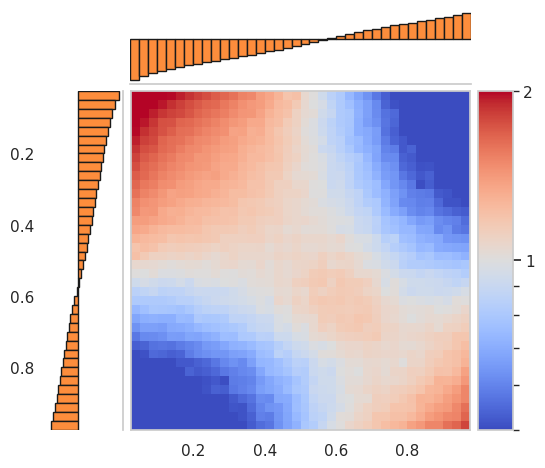

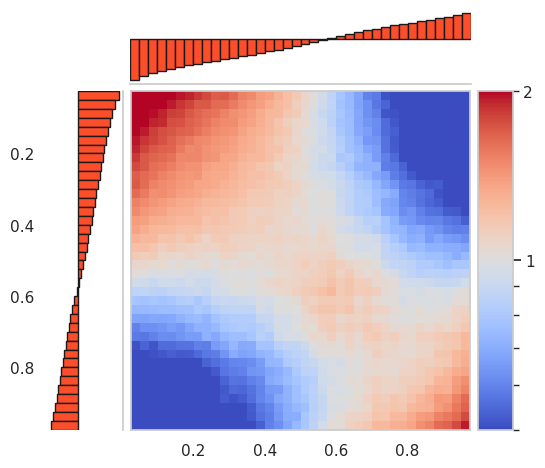

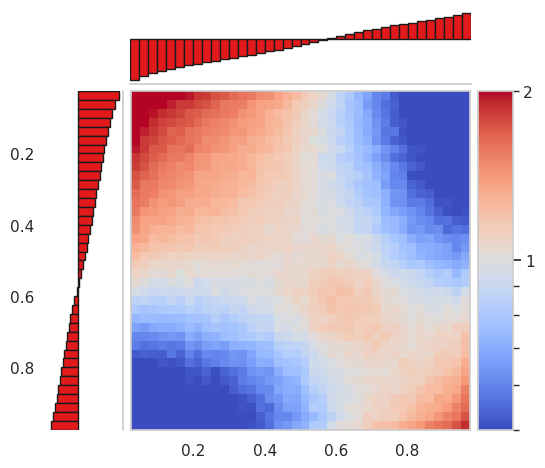

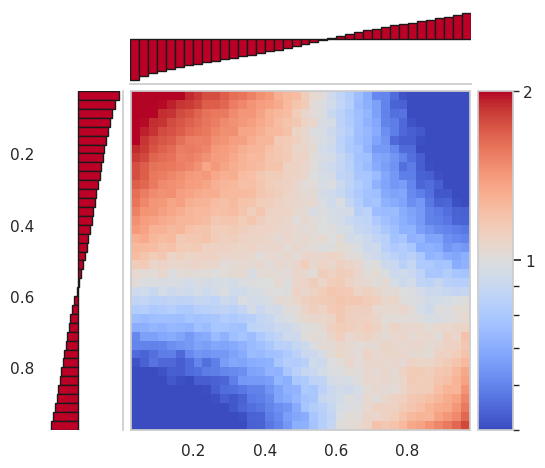

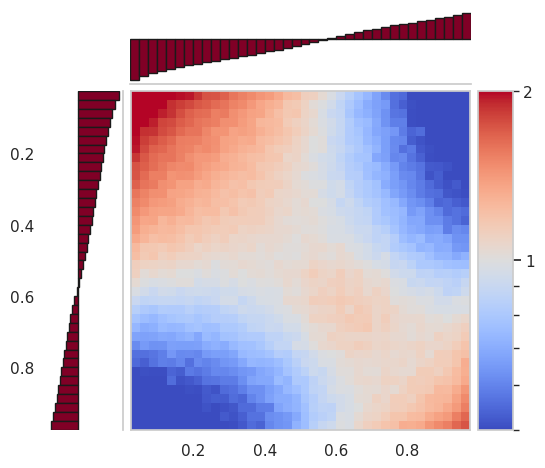

In [58]:
"""
--> to select own eigenvector, use:  eigenvector_track_E1[cond],
--> to select one specific eigenvector, use: eigenvector_track_E1['condition_name']
    
"""
#Turning off some warnings
warnings.filterwarnings("ignore")

for cond in conditions:
    print("calculating... " +cond)
    saddleplot(
#               cis_eigenvector_track_E1['H9_Nup_HB'],
               cis_eigenvector_track_E1['H1_HB'],
               interaction_sum[cond]/interaction_count[cond],
               N_GROUPS,
               qrange=(Q_LO,Q_HI),
#                cbar_kws={'label':'average observed/expected contact frequency'},
#                title=long_names[cond],
               color=colors[cond]
              );
    
    from matplotlib.backends.backend_pdf import PdfPages
    pp = PdfPages(f'{figureDir}/{long_names[cond]}.saddle.pdf')
    plt.savefig(pp, format='pdf')
    pp.close()

# Strength

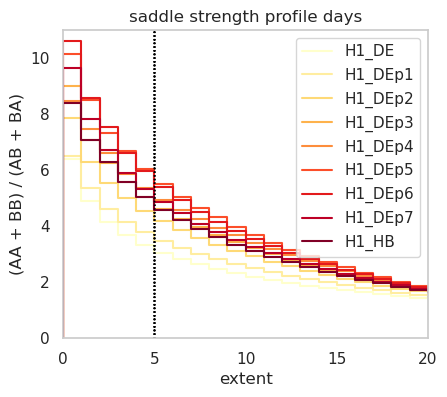

In [63]:
from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)
compartment_strength = {}
gs = plt.GridSpec(nrows=1, ncols=3)
plt.figure(figsize=(16, 4))

for cond in conditions:
    compartment_strength[cond] = saddle_strength(interaction_sum[cond], interaction_count[cond])

extremes = ['DE_R1','DE_R2','H1_DE','H1_HB','H9_Nup_DE','H9_Nup_HB','HB_R1','HB_R2']
H1_only = ['H1_DE','H1_DEp1','H1_DEp2','H1_DEp3','H1_DEp4','H1_DEp5','H1_DEp6','H1_DEp7','H1_HB']
H9_Nup_only = ['H9_Nup_DE','H9_Nup_DEp1','H9_Nup_DEp2','H9_Nup_DEp3','H9_Nup_DEp4','H9_Nup_DEp5','H9_Nup_DEp6','H9_Nup_DEp7','H9_Nup_HB']

#plt.subplot(gs[0])
#for cond in H9_Nup_only:
#    plt.step(x, compartment_strength[cond], where='pre', 
#             label=cond,
#             color=colors[cond],
#             ls='-'
#            )

#    plt.xlabel('extent')
#    plt.ylabel('(AA + BB) / (AB + BA)')
#    plt.title('saddle strength profile H9')
#    plt.axvline(5, c='black', ls=":", lw=1) # Q: is there a reason this is 0 not 1?
#    plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
#    plt.ylim(0, 11); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
#    plt.legend(fontsize='small')
    
plt.subplot(gs[1])

for cond in H1_only:
     plt.step(x, compartment_strength[cond], where='pre', 
              label=cond,
              color=colors[cond],
              ls='-'
             )

     plt.xlabel('extent')
     plt.ylabel('(AA + BB) / (AB + BA)')
     plt.title('saddle strength profile days')
     plt.axvline(5, c='black', ls=":", lw=1) # Q: is there a reason this is 0 not 1?
     plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
     plt.ylim(0, 11); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
     plt.legend()

# plt.subplot(gs[2])

# for cond in extremes:
#     plt.step(x, compartment_strength[cond], where='pre', 
#              label=cond,
#              color=colors[cond],
#              ls='-'
#             )

#     plt.xlabel('extent')
#     plt.ylabel('(AA + BB) / (AB + BA)')
#     plt.title('saddle strength profile days')
#     plt.axvline(5, c='black', ls=":", lw=1) # Q: is there a reason this is 0 not 1?
#     plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
#     plt.ylim(0, 11); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?
#     plt.legend()    
pp = PdfPages(f'{figureDir}/{cond}.strength.pdf')
plt.savefig(pp, format='pdf')
pp.close()

In [64]:
extent_10percent = 5
compartment_str = {}
for cond in conditions:
    compartment_str[cond] = compartment_strength[cond][extent_10percent]

In [65]:
compartment_str

{'H1_DE': 3.33407509546003,
 'H1_DEp1': 3.782946860394271,
 'H1_DEp2': 4.55817347429062,
 'H1_DEp3': 5.036942538720786,
 'H1_DEp4': 5.361167347558907,
 'H1_DEp5': 6.039529535482768,
 'H1_DEp6': 5.956971666869024,
 'H1_DEp7': 5.329731283427393,
 'H1_HB': 5.041143286837534}

In [40]:
compartment_str

{'H9_Nup_DE': 3.7982522682459976,
 'H9_Nup_DEp1': 3.5525792543140766,
 'H9_Nup_DEp2': 3.4601113486735904,
 'H9_Nup_DEp3': 4.596038229464847,
 'H9_Nup_DEp4': 5.46157104283266,
 'H9_Nup_DEp5': 5.763096234032524,
 'H9_Nup_DEp6': 5.664350507284335,
 'H9_Nup_DEp7': 5.340207746700472,
 'H9_Nup_HB': 5.4754133737557105}

In [ ]:
#lable compartment strenght on the corner of saddle

In [41]:
from matplotlib.cm import get_cmap
from cooltools.api.saddle import saddle_strength

In [42]:
#define the function of compartment strength of AA or BB
def saddle_strength_AA(S, C):
    """
    Parameters
    ----------
    S, C : 2D arrays, square, same shape
        Saddle sums and counts, respectively

    Returns
    -------
    1D array
    Ratios of cumulative corner interaction scores, where the saddle data is
    grouped over the AA corners and AB+BA corners with increasing extent.

    """
    m, n = S.shape
    if m != n:
        raise ValueError("`saddledata` should be square.")

    ratios = np.zeros(n)
    for k in range(1, n):
        intra_sum = np.nansum(S[n - k : n, n - k : n])
        intra_count = np.nansum(C[n - k : n, n - k : n])
        intra = intra_sum / intra_count

        inter_sum = np.nansum(S[0:k, n - k : n]) + np.nansum(S[n - k : n, 0:k])
        inter_count = np.nansum(C[0:k, n - k : n]) + np.nansum(C[n - k : n, 0:k])
        inter = inter_sum / inter_count

        ratios[k] = intra / inter
    return ratios

def saddle_strength_BB(S, C):
    """
    Parameters
    ----------
    S, C : 2D arrays, square, same shape
        Saddle sums and counts, respectively

    Returns
    -------
    1D array
    Ratios of cumulative corner interaction scores, where the saddle data is
    grouped over the BB corners and AB+BA corners with increasing extent.

    """
    m, n = S.shape
    if m != n:
        raise ValueError("`saddledata` should be square.")

    ratios = np.zeros(n)
    for k in range(1, n):
        intra_sum = np.nansum(S[0:k, 0:k])
        intra_count = np.nansum(C[0:k, 0:k])
        intra = intra_sum / intra_count

        inter_sum = np.nansum(S[0:k, n - k : n]) + np.nansum(S[n - k : n, 0:k])
        inter_count = np.nansum(C[0:k, n - k : n]) + np.nansum(C[n - k : n, 0:k])
        inter = inter_sum / inter_count

        ratios[k] = intra / inter
    return ratios

plotting... H1_DE


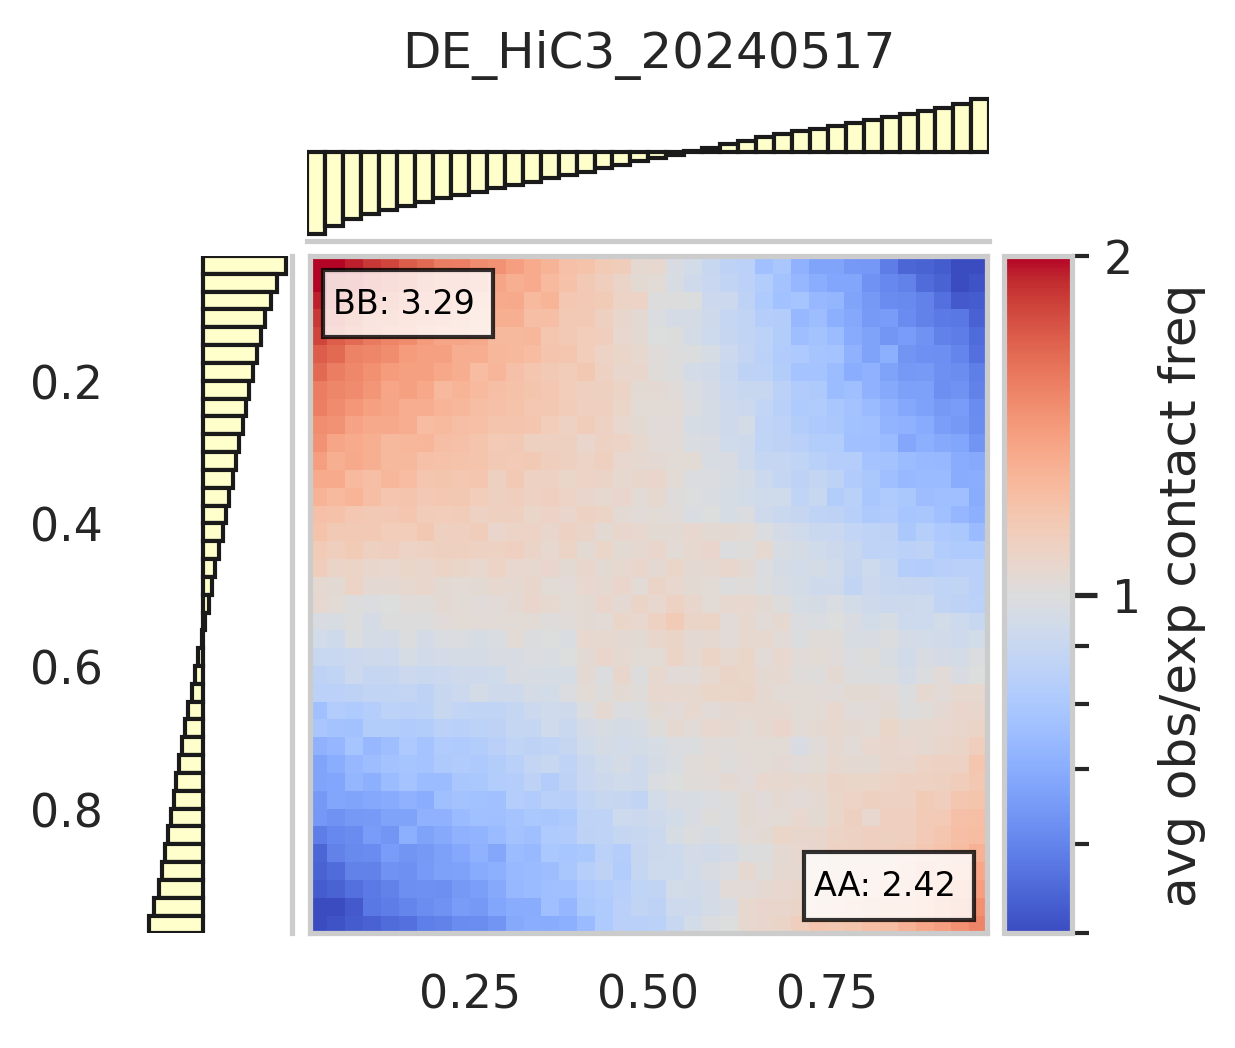

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DE_HiC3_20240517.saddle.pdf
plotting... H1_DEp1


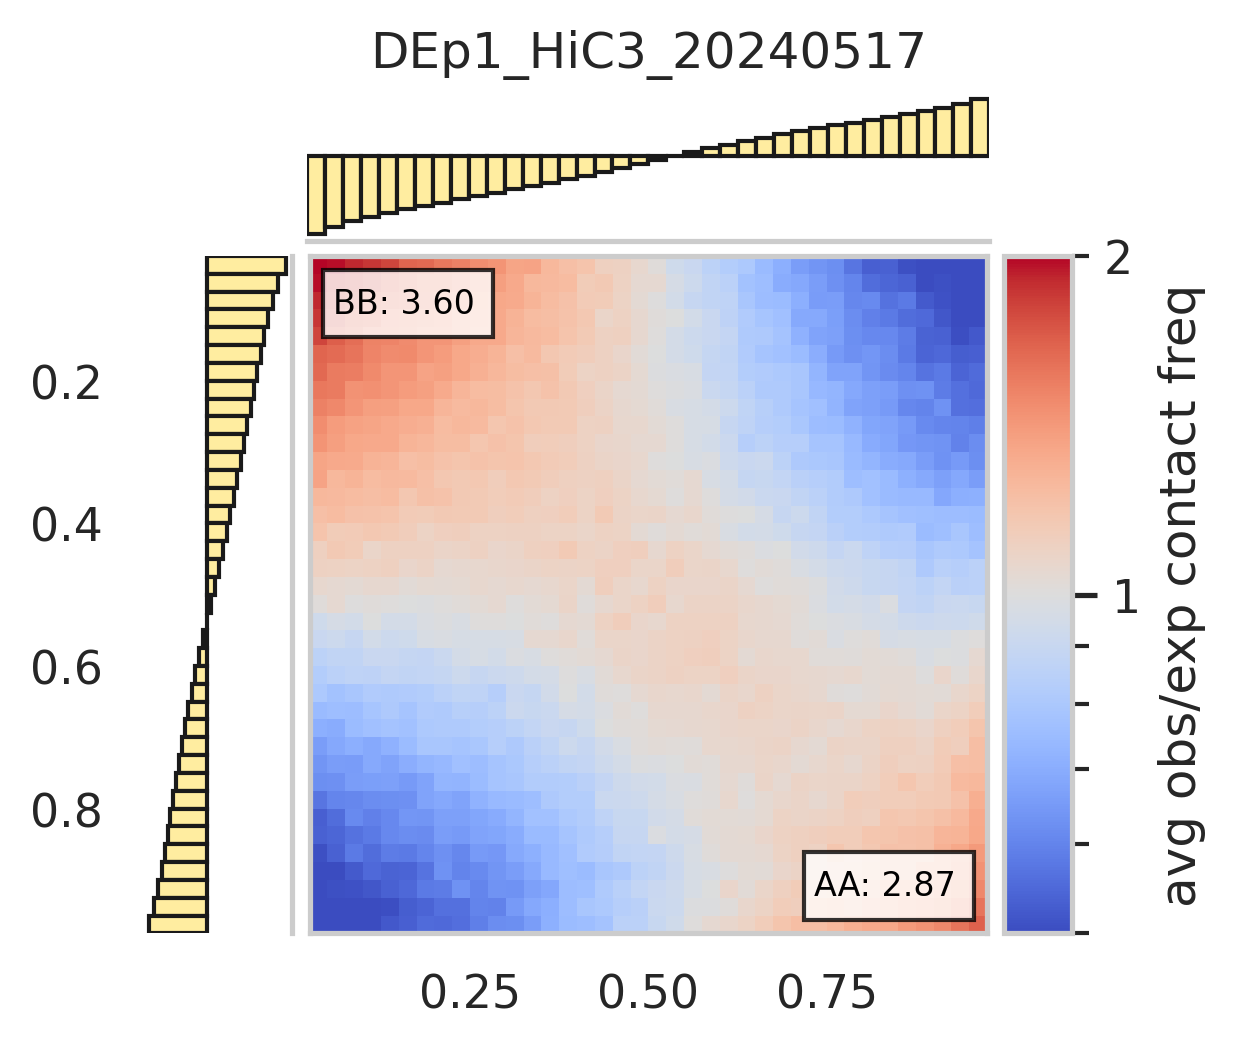

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp1_HiC3_20240517.saddle.pdf
plotting... H1_DEp2


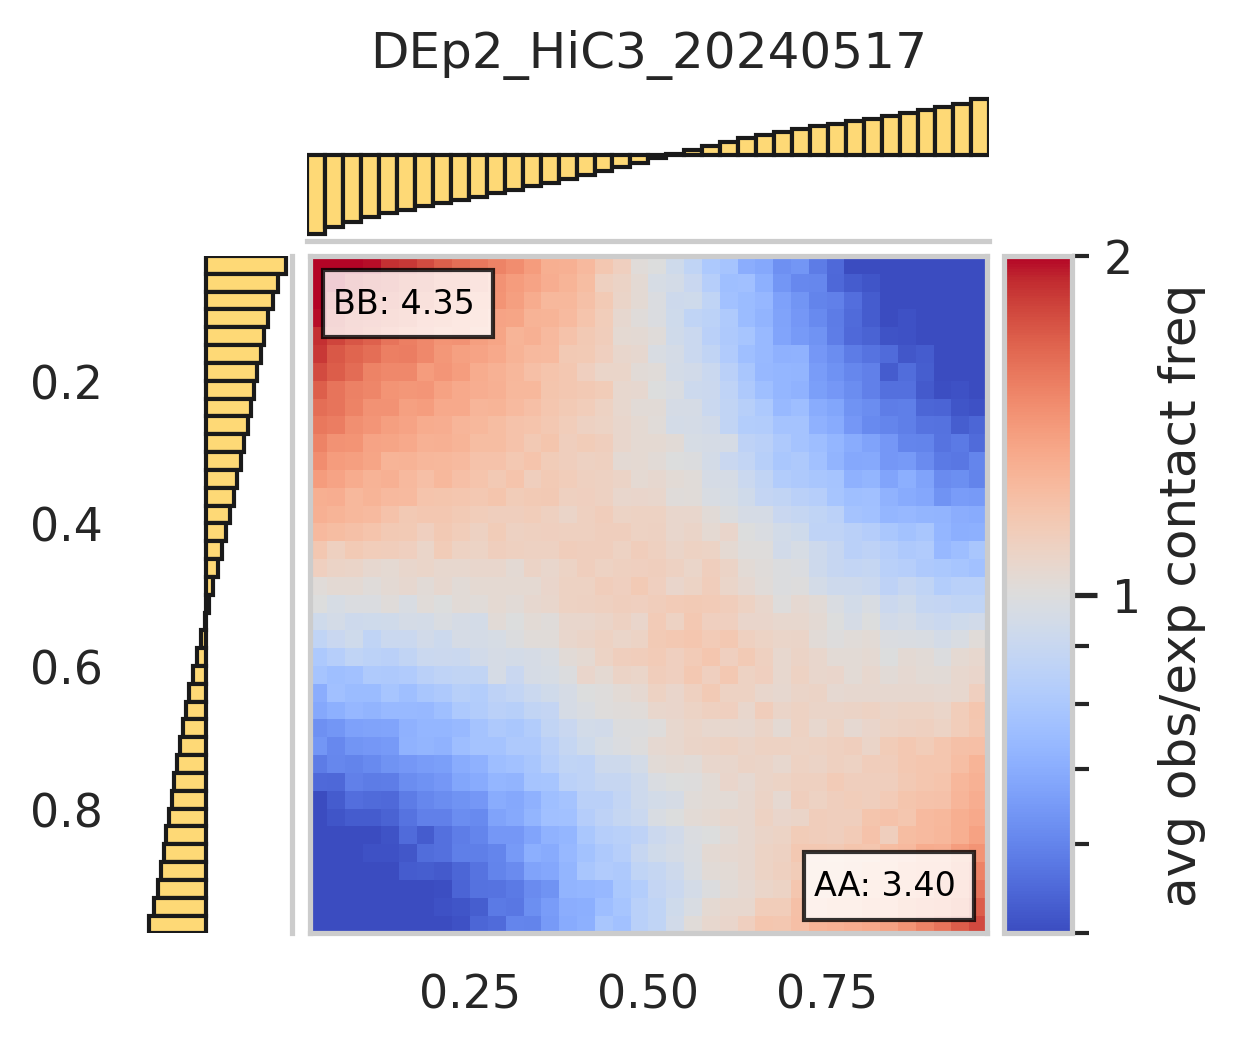

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp2_HiC3_20240517.saddle.pdf
plotting... H1_DEp3


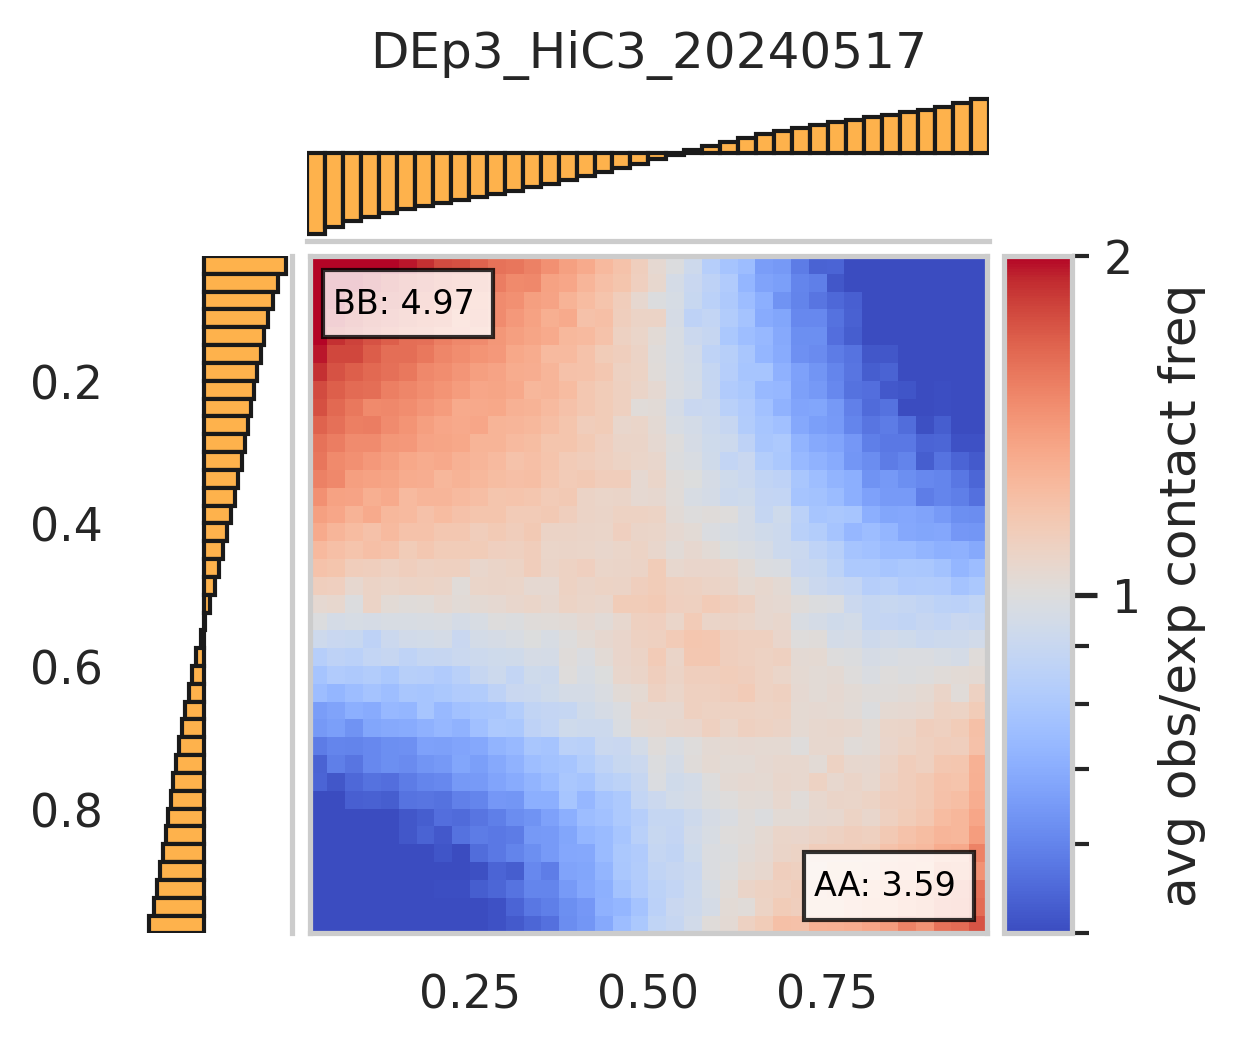

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp3_HiC3_20240517.saddle.pdf
plotting... H1_DEp4


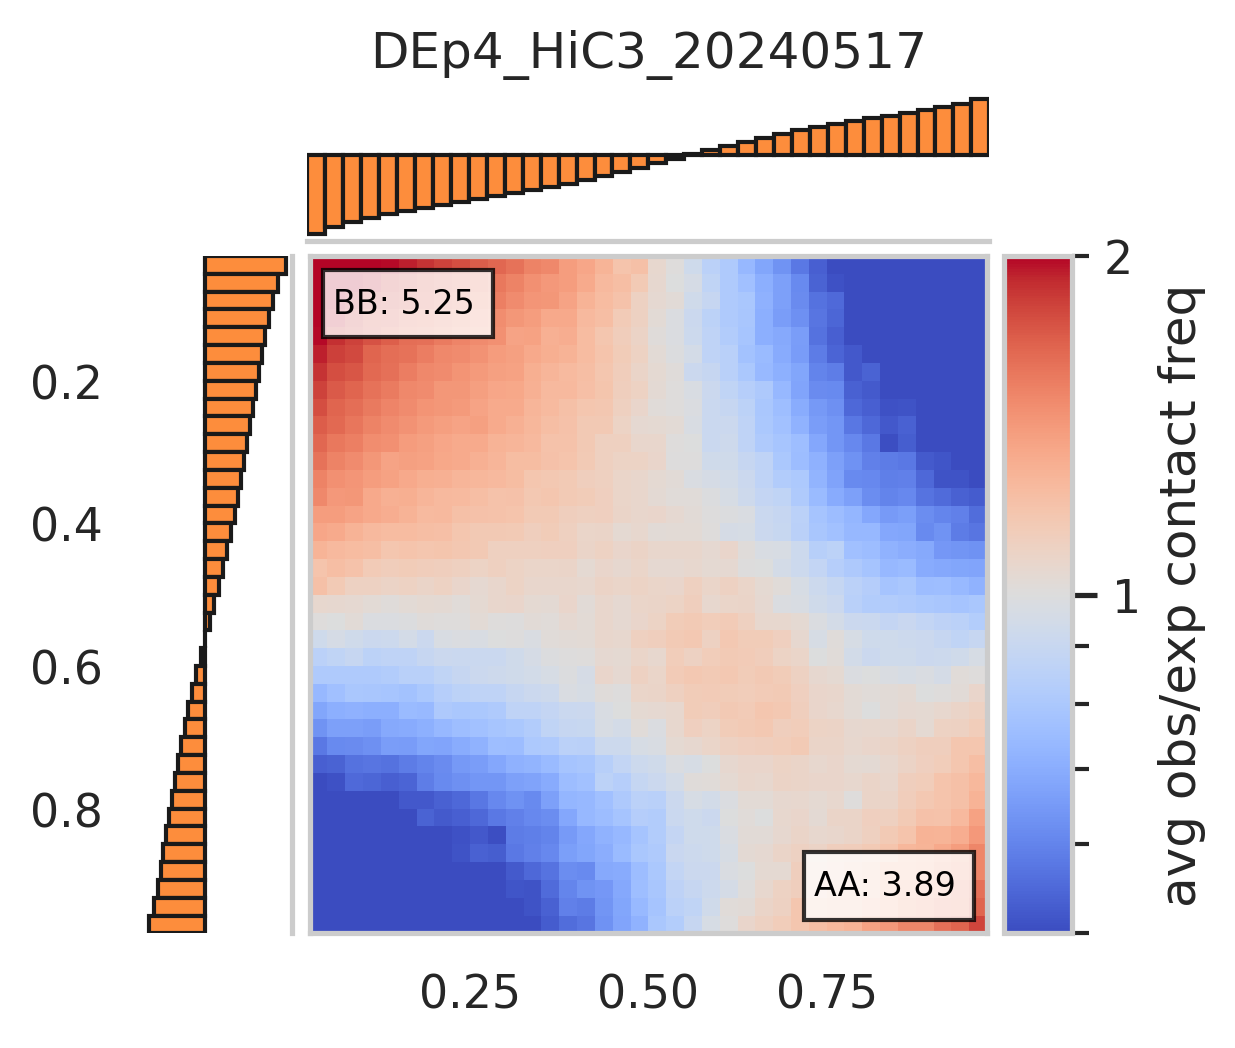

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp4_HiC3_20240517.saddle.pdf
plotting... H1_DEp5


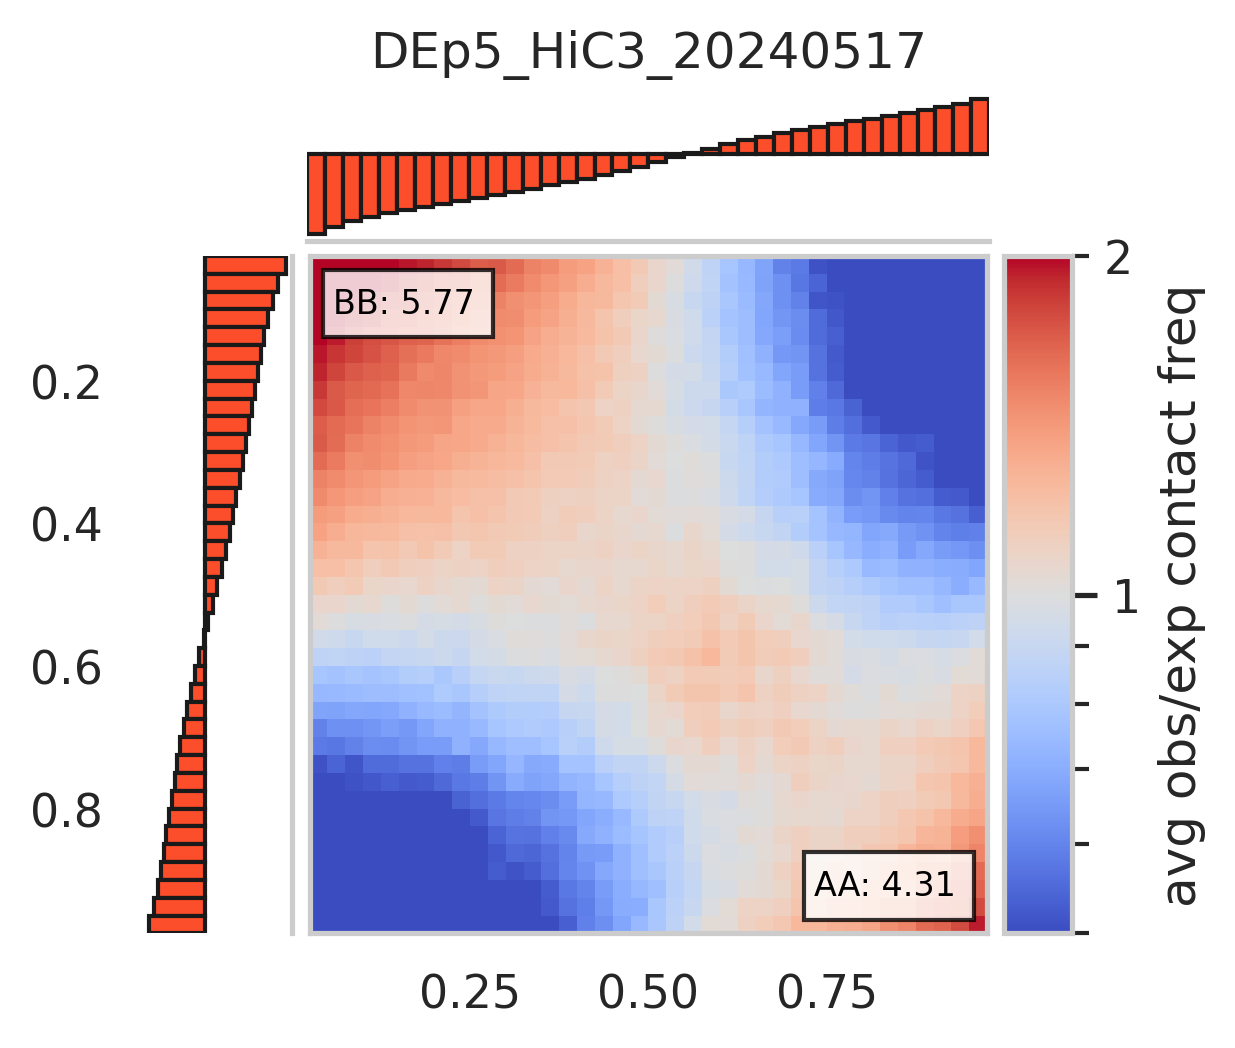

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp5_HiC3_20240517.saddle.pdf
plotting... H1_DEp6


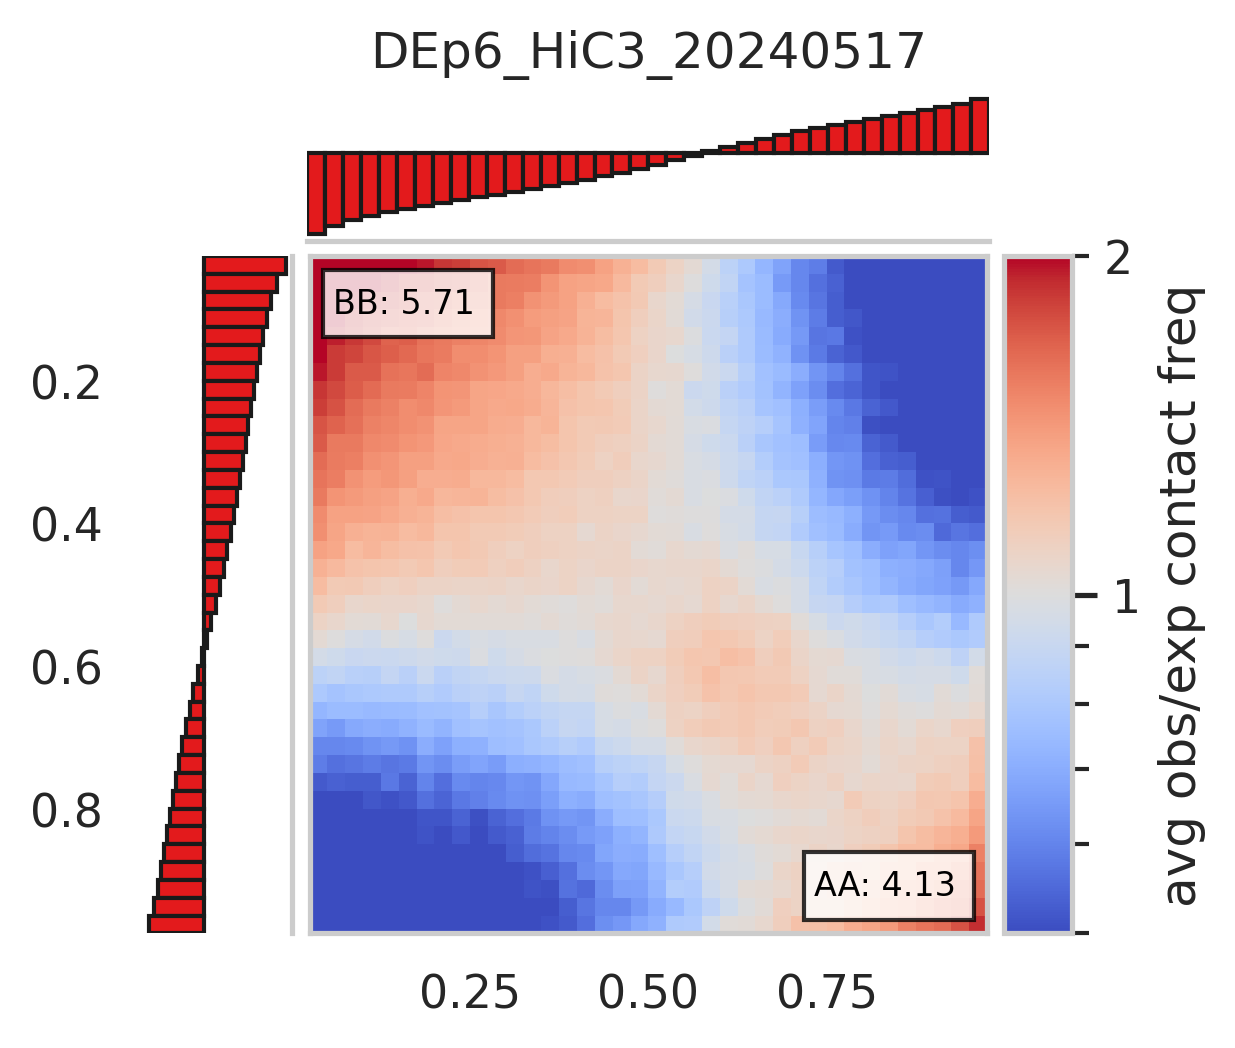

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp6_HiC3_20240517.saddle.pdf
plotting... H1_DEp7


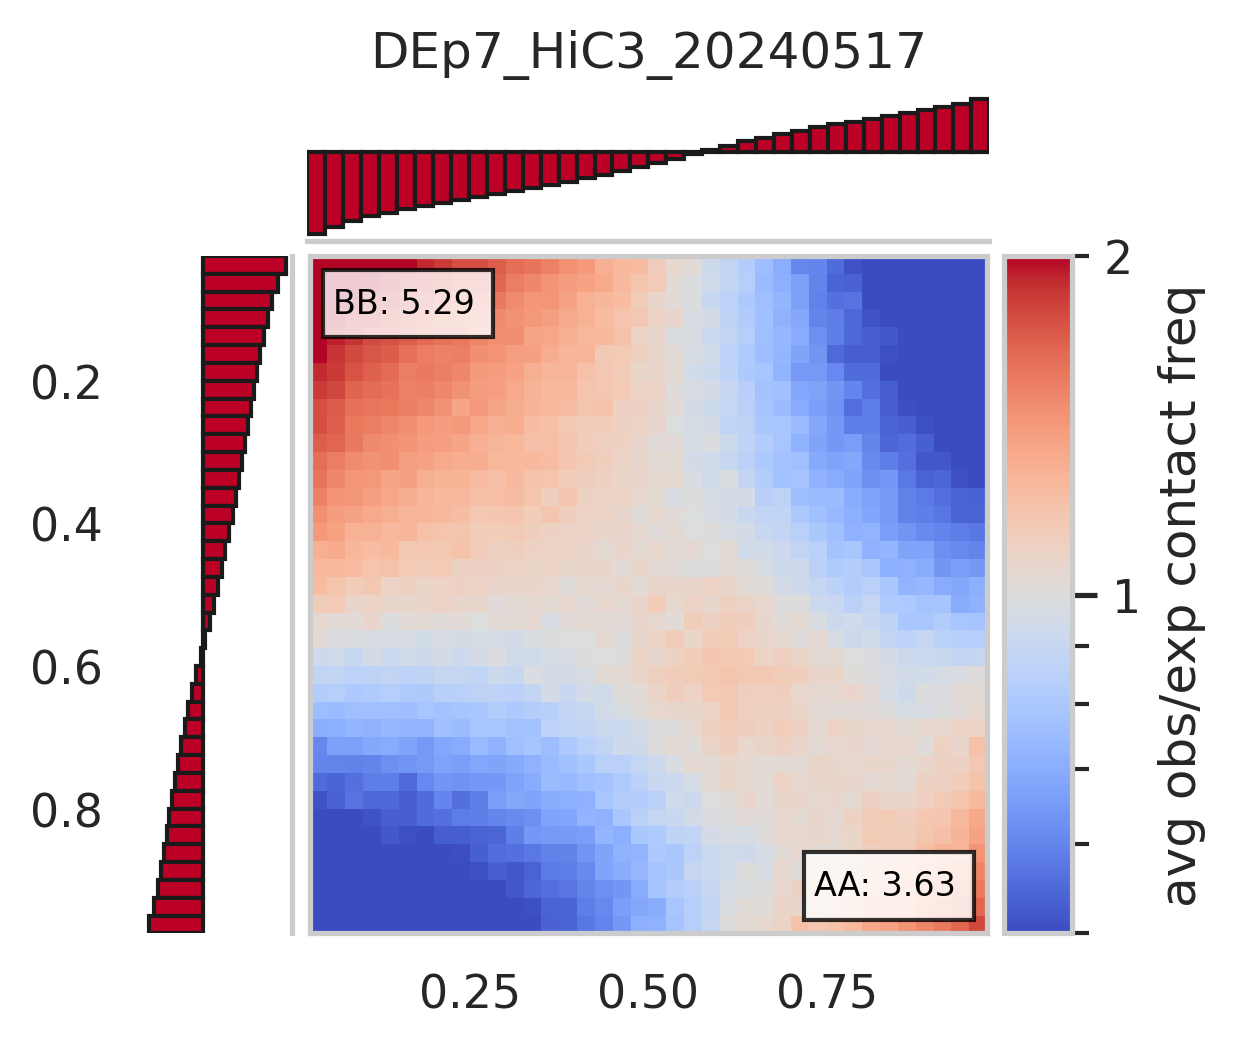

saved: /sharehome/xiangruhuo/4DN_scripts/plot/DEp7_HiC3_20240517.saddle.pdf
plotting... H1_HB


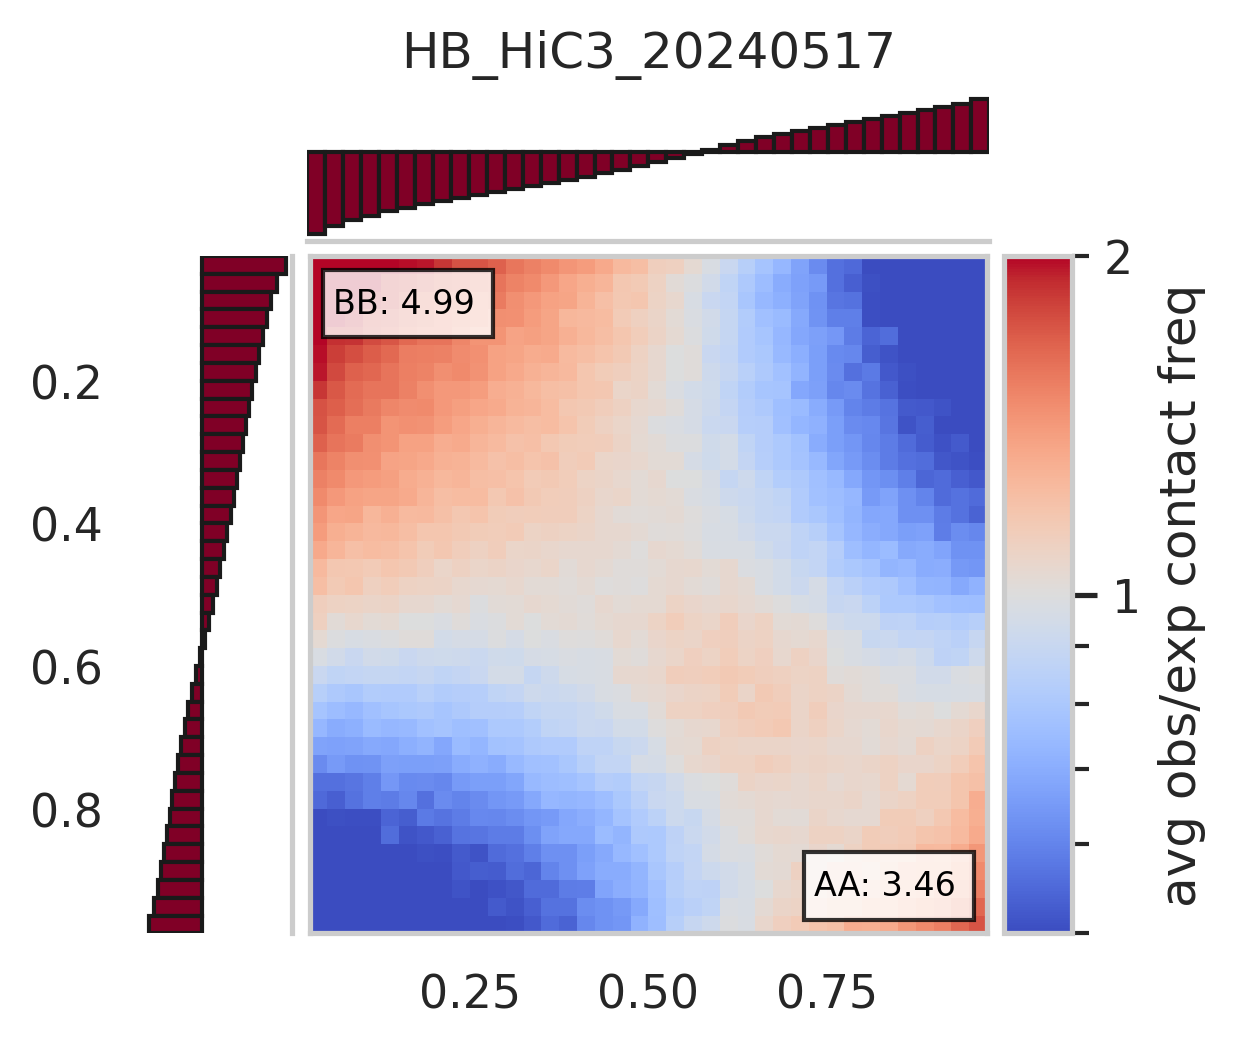

saved: /sharehome/xiangruhuo/4DN_scripts/plot/HB_HiC3_20240517.saddle.pdf


In [66]:
# Turn off warnings
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

save_dir = figureDir
os.makedirs(save_dir, exist_ok=True)

Top = 0.2

for cond in conditions:
    print("plotting...", cond)

    # -------------------------
    # Calculate saddle average
    # -------------------------
    saddle_avg = interaction_sum[cond] / interaction_count[cond]

    # -------------------------
    # Create figure
    # -------------------------
    fig = plt.figure(figsize=(4, 4), dpi=300)

    # -------------------------
    # Plot saddle
    # IMPORTANT: use cond-specific E1 track
    # -------------------------
    grid = saddleplot(
        cis_eigenvector_track_E1[cond][["chrom", "start", "end", "E1"]],
        saddle_avg,
        N_GROUPS,
        qrange=(Q_LO, Q_HI),
        title=long_names[cond],
        cbar_kws={"label": "avg obs/exp contact freq"},
        color=colors[cond],
        fig=fig
    )

    ax = grid["ax_heatmap"]

    # -------------------------
    # Calculate AA / BB saddle strength
    # -------------------------
    ss_AA = saddle_strength_AA(
        interaction_sum[cond],
        interaction_count[cond]
    )

    ss_BB = saddle_strength_BB(
        interaction_sum[cond],
        interaction_count[cond]
    )

    k = int(len(ss_AA) * Top) - 1

    AA_strength = ss_AA[k]
    BB_strength = ss_BB[k]

    # -------------------------
    # Annotate B-B in top-left corner
    # -------------------------
    ax.add_patch(
        Rectangle(
            (0.02, 0.88),
            0.25,
            0.10,
            transform=ax.transAxes,
            edgecolor="black",
            facecolor="white",
            alpha=0.8,
            lw=1
        )
    )

    ax.text(
        0.035,
        0.93,
        f"BB: {BB_strength:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=8,
        color="black"
    )

    # -------------------------
    # Annotate A-A in bottom-right corner
    # -------------------------
    ax.add_patch(
        Rectangle(
            (0.73, 0.02),
            0.25,
            0.10,
            transform=ax.transAxes,
            edgecolor="black",
            facecolor="white",
            alpha=0.8,
            lw=1
        )
    )

    ax.text(
        0.745,
        0.07,
        f"AA: {AA_strength:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=8,
        color="black"
    )

    # -------------------------
    # Save
    # -------------------------
    save_path = f"{save_dir}/{long_names[cond]}.saddle.pdf"

    fig.savefig(
        save_path,
        format="pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("saved:", save_path)